In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

import urllib.request

from torchvision import models, transforms
from PIL import Image

import sys
sys.path.append('../modelling')

import utils

## Load model and sample image

In [2]:
def preprocess_image(img_path):

    """Load and preprocess images for PyTorch models."""

    img = Image.open(img_path).convert("RGB")

    #Transforms used by imagenet models
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    return transform(img).unsqueeze(0)

def display_output(output,n=5):

    """Display the top n categories predicted by the model."""
    
    # Download the categories
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    urllib.request.urlretrieve(url, "imagenet_classes.txt")

    with open("imagenet_classes.txt", "r") as f:
        categories = [s.strip() for s in f.readlines()]

    # Show top categories per image
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_prob, top_catid = torch.topk(probabilities, n)

    for i in range(top_prob.size(0)):
        print(categories[top_catid[i]], top_prob[i].item())

    return top_catid[0]

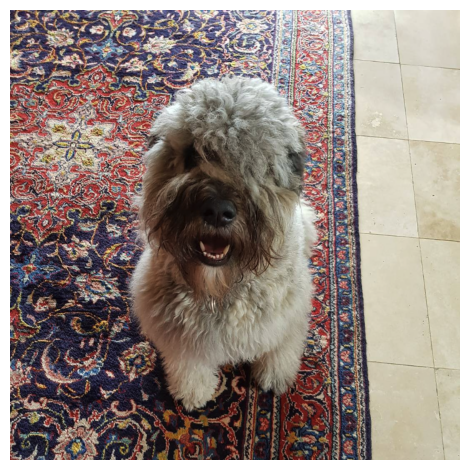

In [3]:
# Load a sample image
img_path = "dog.png"
img = Image.open(img_path).convert("RGB")

plt.imshow(img)
plt.axis("off")

# Save figure
utils.save_fig("guidedbackprop_dog")

In [4]:
# Load the pre-trained model (e.g., VGG16)
model = models.vgg16(pretrained=True)

# Set the model to gpu
device = torch.device('mps' if torch.backends.mps.is_built() 
                      else 'cuda' if torch.cuda.is_available() 
                      else 'cpu')
model.to(device)

# Set the model to evaluation mode
model.eval()

/Users/conorosullivan/Documents/git/XAI-for-CV/cv_xai_venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/conorosullivan/Documents/git/XAI-for-CV/cv_xai_venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [5]:
# Preprocess the image
original_img_tensor = preprocess_image(img_path)
original_img_tensor = original_img_tensor.to(device)

# Clone tensor to avoid in-place operations
img_tensor = original_img_tensor.clone()
img_tensor.requires_grad_() # Enable gradient tracking

predictions = model(img_tensor)

# Decode the output
display_output(predictions)

Lhasa 0.30986806750297546
soft-coated wheaten terrier 0.25563883781433105
Bouvier des Flandres 0.15312978625297546
Shih-Tzu 0.11231262981891632
Old English sheepdog 0.0692916065454483


tensor(204, device='mps:0')

In [6]:
# Select the class with the highest score
target_class = predictions.argmax()

# Reset gradients
model.zero_grad() 

# Compute gradients w.r.t to logit by performing backward pass
predictions[:, target_class].backward()

standard_backprop_grads = img_tensor.grad.detach().cpu().numpy() #do not detach the gradient
print(standard_backprop_grads.shape) # (1, 3, 224, 224)

(1, 3, 224, 224)


In [7]:
def process_grads(grads_in,activation="None",skew=True,normalize=True,greyscale=False):
    """
    Process the gradients for visualization.

    Parameters:
        grads (np.array): Gradients to be processed.
        activation (str): Activation function to be applied to the gradients. Options: "relu", "abs".
        skew (bool): Whether to skew the gradients.

    Returns:
        np.array: Processed gradients.
    """
    # Copy the gradients
    grads = np.copy(grads_in)
    
    # Transpose the gradients
    if len(grads.shape) >= 3:
        grads = np.transpose(grads, (1, 2, 0))

    # Get the absolute value of the gradients
    if activation == "relu":
        grads = np.maximum(0, grads)
    elif activation == "abs":
        grads = np.abs(grads)
    else:
        grads = grads

    # Normalize the gradients
    if normalize:
        grads -= np.min(grads)
        grads /= np.max(grads)

    # Skew the gradients
    if skew:
        grads = np.sqrt(grads)

    # Convert the gradients to greyscale
    if greyscale:
        grads = np.mean(grads, axis=-1)

    return grads

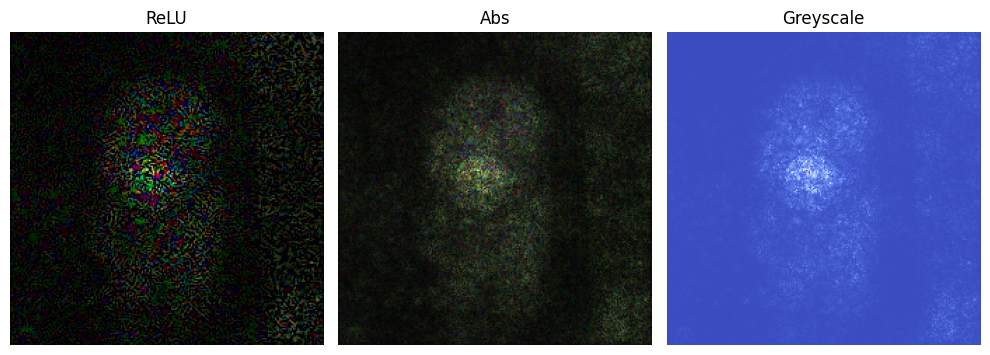

In [8]:
grads = standard_backprop_grads[0]

# Process the gradients
relu_grads = process_grads(grads,activation="relu")
abs_grads = process_grads(grads,activation="abs")
grey_grads = process_grads(grads,activation="abs",greyscale=True,skew=False)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

# Display as an image
im0 = ax[0].imshow(relu_grads)
ax[0].title.set_text("ReLU")

im1 = ax[1].imshow(abs_grads)
ax[1].title.set_text("Abs")

im2 = ax[2].imshow(grey_grads, cmap="coolwarm")
ax[2].title.set_text("Greyscale")

for a in ax:
    a.axis("off")

# Save figure
utils.save_fig("guided_backprop_standard")

## Hooks for Guided-Backprop

In [9]:
def relu_hook(module, grad_in, grad_out):
    """
    Guided Backpropagation Hook: Allows only positive gradients to backpropagate.

    Parameters:
        module (nn.Module): The module where the hook is applied.
        grad_in (tuple of Tensors): Gradeints w.r.t. the input of the module.
        grad_out (tuple of Tensors): Gradients w.r.t. the output of the module.
    """
    
    # Remove negative gradients
    modified_grad = torch.clamp(grad_in[0], min=0.0)

    # All PyTorch gradeints are stored as tuples
    modified_grad = tuple(modified_grad)

    # Return the modified gradients and continue backpropagation
    return modified_grad  

In [10]:
# Dictionary to store gradients
gradients = {}

def conv_hook(module, grad_in, grad_out, layer_name):
    """
    Hook to store gradients of convolutional layers.

    Parameters:
        module (nn.Module): The module where the hook is applied.
        grad_in (tuple of Tensors): Gradients w.r.t the input of the layer.
        grad_out (tuple of Tensors): Gradients w.r.t the output of the layer.
        layer_name (str): Name of the layer.
    """

    # Save gradients of conv layers
    grad_out = grad_out[0].detach().cpu().numpy().squeeze()
    gradients[layer_name] = grad_out
    
    print(f"Gradients stored for {layer_name}")

In [11]:
# Register the hook for all layers
for name, layer in model.named_modules():

    # Update the hook for ReLU layers
    if isinstance(layer, torch.nn.ReLU):
        layer.register_backward_hook(relu_hook)
        print(f"Relu hook registered for {name}")
    
    # save gradients for conv layers
    elif isinstance(layer, torch.nn.Conv2d) :
        layer.register_backward_hook(lambda m, 
                                     gi, 
                                     go, 
                                     n=name: 
                                     conv_hook(m, gi, go, n))
        print(f"Conv hook registered for {name}")

Conv hook registered for features.0
Relu hook registered for features.1
Conv hook registered for features.2
Relu hook registered for features.3
Conv hook registered for features.5
Relu hook registered for features.6
Conv hook registered for features.7
Relu hook registered for features.8
Conv hook registered for features.10
Relu hook registered for features.11
Conv hook registered for features.12
Relu hook registered for features.13
Conv hook registered for features.14
Relu hook registered for features.15
Conv hook registered for features.17
Relu hook registered for features.18
Conv hook registered for features.19
Relu hook registered for features.20
Conv hook registered for features.21
Relu hook registered for features.22
Conv hook registered for features.24
Relu hook registered for features.25
Conv hook registered for features.26
Relu hook registered for features.27
Conv hook registered for features.28
Relu hook registered for features.29
Relu hook registered for classifier.1
Relu hoo

In [12]:
# Replace all in-place ReLU activations with out-of-place ones
def replace_relu(model):

    for name, child in model.named_children():
        if isinstance(child, torch.nn.ReLU):
            setattr(model, name, torch.nn.ReLU(inplace=False))
            print(f"Replacing ReLU activation in layer: {name}")
        else:
            replace_relu(child)  # Recursively apply to submodules

# Apply the modification to the VGG16 model
replace_relu(model)

Replacing ReLU activation in layer: 1
Replacing ReLU activation in layer: 3
Replacing ReLU activation in layer: 6
Replacing ReLU activation in layer: 8
Replacing ReLU activation in layer: 11
Replacing ReLU activation in layer: 13
Replacing ReLU activation in layer: 15
Replacing ReLU activation in layer: 18
Replacing ReLU activation in layer: 20
Replacing ReLU activation in layer: 22
Replacing ReLU activation in layer: 25
Replacing ReLU activation in layer: 27
Replacing ReLU activation in layer: 29
Replacing ReLU activation in layer: 1
Replacing ReLU activation in layer: 4


## Guided-backprop for target logit

In [13]:
# Reset gradients
img_tensor = original_img_tensor.clone()
img_tensor.requires_grad_()
model.zero_grad() 

# Get the model's prediction (with gradient calculation)
predictions = model(img_tensor)

# Select the class with the highest score
target_class = predictions.argmax()

# Compute gradients w.r.t to logit by performing backward pass
predictions[:, target_class].backward()

Gradients stored for features.28
Gradients stored for features.26
Gradients stored for features.24
Gradients stored for features.21
Gradients stored for features.19
Gradients stored for features.17
Gradients stored for features.14
Gradients stored for features.12
Gradients stored for features.10
Gradients stored for features.7
Gradients stored for features.5
Gradients stored for features.2
Gradients stored for features.0


/Users/conorosullivan/Documents/git/XAI-for-CV/cv_xai_venv/lib/python3.11/site-packages/torch/nn/modules/module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


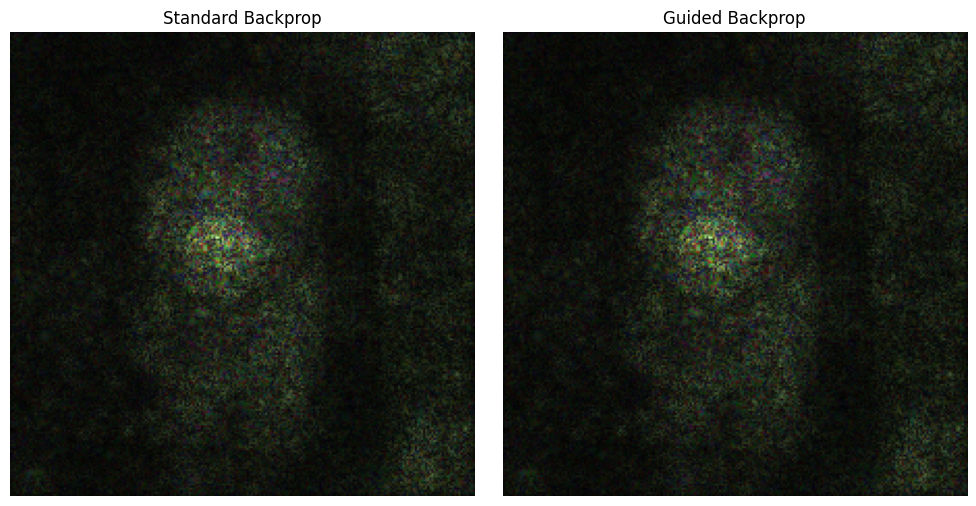

In [14]:
# Get the image gradients
grads = img_tensor.grad.detach().cpu().numpy().squeeze()

grads = process_grads(grads,activation="abs")

fig,ax = plt.subplots(1,2,figsize=(10,5))

# Display the gradients
ax[0].imshow(abs_grads)
ax[0].title.set_text("Standard Backprop")

ax[1].imshow(grads)
ax[1].title.set_text("Guided Backprop")

for a in ax:
    a.axis("off")

# Save figure
utils.save_fig("guided_backprop_logit_input")

## Guided backprop from intermediate layers

(64, 224, 224)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

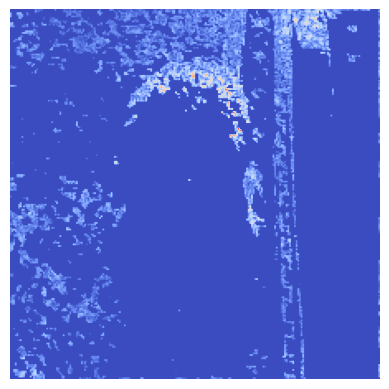

In [15]:
# Gradients from the first layer
layer = 'features.0'

# Get gradients for all feature map in layer
layer_grads = gradients[layer]
print(layer_grads.shape)

# Select a random feature map
i = np.random.randint(0, layer_grads.shape[0])
feature_map_grads = layer_grads[i]

# Processing the gradients
feature_map_grads = process_grads(feature_map_grads, activation="abs")

# Display the gradients
plt.imshow(feature_map_grads, cmap="coolwarm")
plt.axis("off")


features.0: (64, 224, 224)
features.7: (128, 112, 112)
features.14: (256, 56, 56)
features.24: (512, 14, 14)


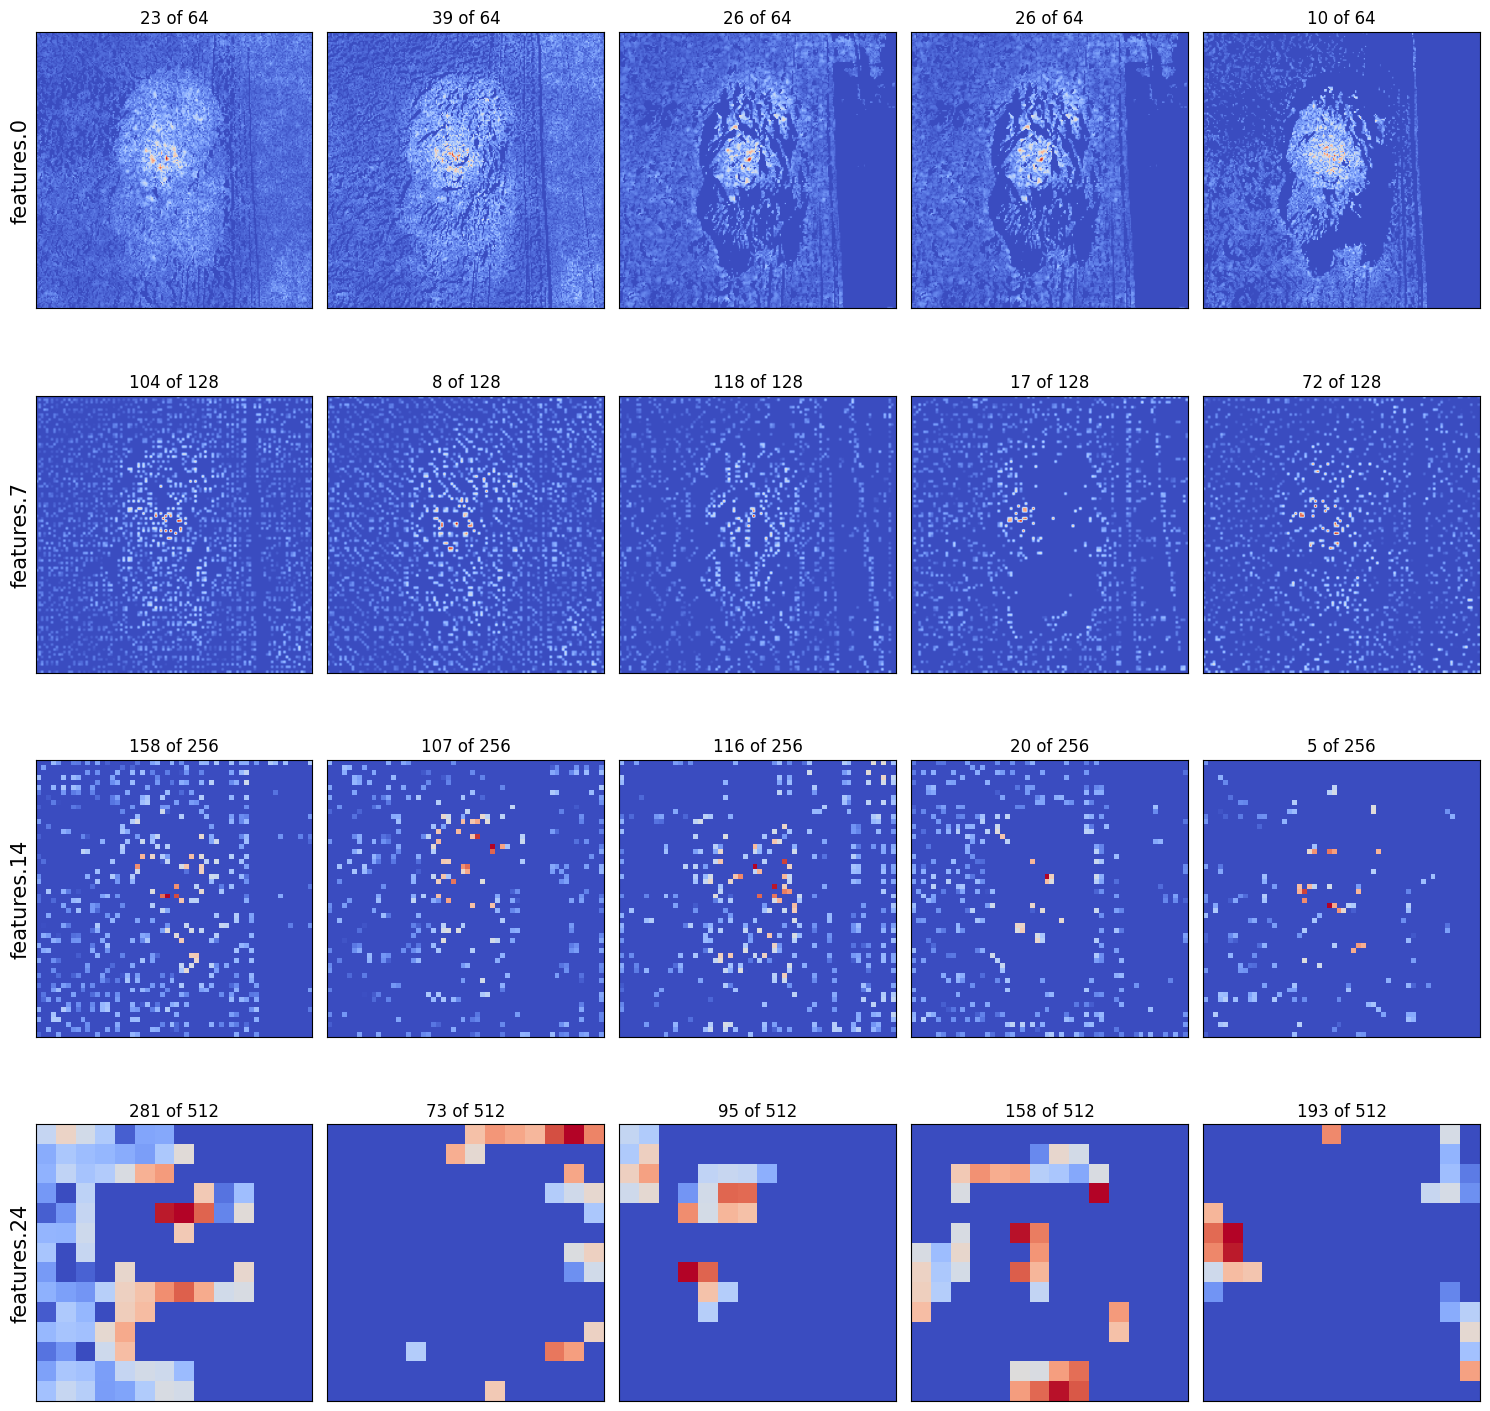

In [16]:
fig, ax = plt.subplots(4, 5, figsize=(15, 15))

for i,layer in enumerate(['features.0','features.7','features.14','features.24']):
    layer_grads = gradients[layer]
    print(f"{layer}: {layer_grads.shape}")

    for j in range(5):
        n_features = layer_grads.shape[0]
        r = np.random.randint(0, n_features)

        feature_map_grads = layer_grads[r]
        feature_map_grads = process_grads(feature_map_grads, activation="abs")

        ax[i, j].imshow(feature_map_grads, cmap="coolwarm")
    
        ax[i, j].set_title(f"{r} of {n_features}")
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
          
    ax[i, 0].set_ylabel(f"{layer}", fontsize=15)

plt.tight_layout()

# Save figure
#utils.save_fig("guided_backprop_feature_maps")
       

## Guided backprop from activations

In [17]:
# Dictionary to store activations
activations = {}

def act_hook_fn(module, input, output, layer_name):
    """
    Hook function to store activations of a layer.

    Parameters:
        module (nn.Module): The module where the hook is applied.
        input (tuple of Tensors): Incoming data to the layer.
        output (Tensor): Outgoing data from the layer.
        layer_name (str): The name of the layer.
    """
    # Store the activations as tensors
    activations[layer_name] = output.clone()
    print(f"Activation stored for {layer_name}")


# Register hooks on all convolutional layers
for name, layer in model.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        layer.register_forward_hook(lambda m, i, o, n=name: act_hook_fn(m, i, o, n))
        print(f"Forward hook registered for {name}")

Forward hook registered for features.0
Forward hook registered for features.2
Forward hook registered for features.5
Forward hook registered for features.7
Forward hook registered for features.10
Forward hook registered for features.12
Forward hook registered for features.14
Forward hook registered for features.17
Forward hook registered for features.19
Forward hook registered for features.21
Forward hook registered for features.24
Forward hook registered for features.26
Forward hook registered for features.28


In [27]:
# Reset gradients
img_tensor = original_img_tensor.clone()
img_tensor.requires_grad_() 
model.zero_grad()

# Perform a forward pass
predictions = model(img_tensor)

# Get the activations of the conv layers
layer_act = activations['features.21'][0]
print(layer_act.shape) # (512, 28, 28)

Activation stored for features.0
Activation stored for features.2
Activation stored for features.5
Activation stored for features.7
Activation stored for features.10
Activation stored for features.12
Activation stored for features.14
Activation stored for features.17
Activation stored for features.19
Activation stored for features.21
Activation stored for features.24
Activation stored for features.26
Activation stored for features.28
torch.Size([512, 28, 28])


/Users/conorosullivan/Documents/git/XAI-for-CV/cv_xai_venv/lib/python3.11/site-packages/torch/nn/modules/module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


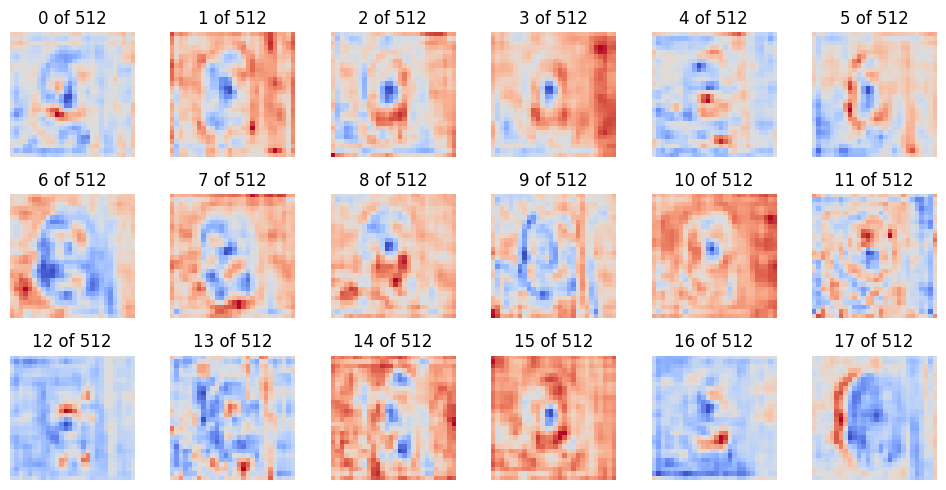

In [35]:
# Plot the activations
fig, ax = plt.subplots(3, 6, figsize=(10, 5))

for i, act in enumerate(layer_act[0:18]):

    act_copy = act.clone().detach().cpu().numpy()
    act_copy = process_grads(act_copy,skew= False)
    
    ax[i // 6, i % 6].imshow(act_copy, cmap="coolwarm")
    ax[i // 6, i % 6].set_title(f"{i} of {layer_act.shape[0]}")
    ax[i // 6, i % 6].axis("off")

plt.tight_layout()

# Save figure
utils.save_fig("guided_backprop_activations_features_21")

In [36]:
# Compute gradients w.r.t element of the activation map
layer_act[0][14,14].backward()

Gradients stored for features.21
Gradients stored for features.19
Gradients stored for features.17
Gradients stored for features.14
Gradients stored for features.12
Gradients stored for features.10
Gradients stored for features.7
Gradients stored for features.5
Gradients stored for features.2
Gradients stored for features.0


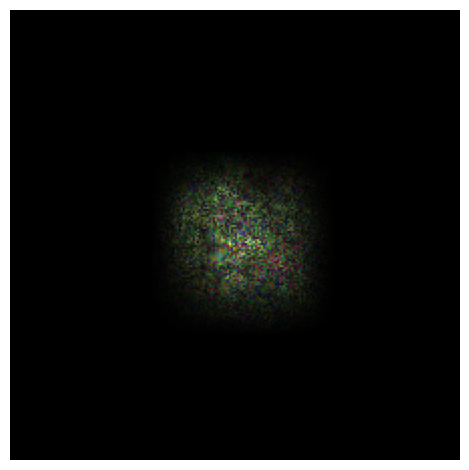

In [38]:
# Get the gradients of input image
grads = img_tensor.grad.detach().cpu().numpy().squeeze()

grads = process_grads(grads, activation="abs")

plt.imshow(grads)
plt.axis("off")

# Save figure
utils.save_fig("guided_backprop_activation_grad")

Activation stored for features.0
Activation stored for features.2
Activation stored for features.5
Activation stored for features.7
Activation stored for features.10
Activation stored for features.12
Activation stored for features.14
Activation stored for features.17
Activation stored for features.19
Activation stored for features.21
Activation stored for features.24
Activation stored for features.26
Activation stored for features.28
Gradients stored for features.21
Gradients stored for features.19
Gradients stored for features.17
Gradients stored for features.14
Gradients stored for features.12
Gradients stored for features.10
Gradients stored for features.7
Gradients stored for features.5
Gradients stored for features.2
Gradients stored for features.0
Activation stored for features.0
Activation stored for features.2
Activation stored for features.5
Activation stored for features.7
Activation stored for features.10
Activation stored for features.12
Activation stored for features.14
Ac

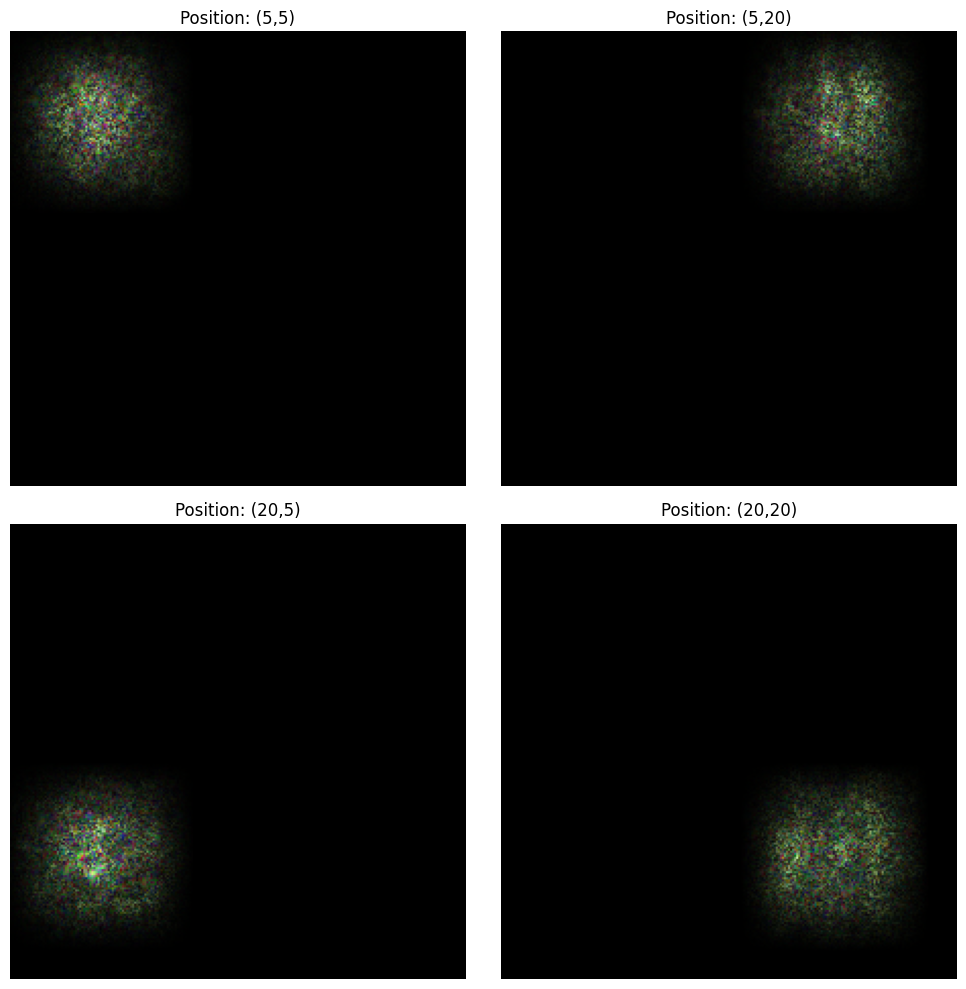

In [39]:
positions = [(5,5),(5,20),(20,5),(20,20)]

fig,ax = plt.subplots(2,2,figsize=(10,10))

for i, (x,y) in enumerate(positions):

    img_tensor = original_img_tensor.clone()
    img_tensor.requires_grad_()
    model.zero_grad() # Reset gradients

    predictions = model(img_tensor)

    # Get the activations of the conv layers
    layer_act = activations['features.21'][0]
    layer_act[0][x,y].backward()

    grads = img_tensor.grad.cpu().numpy().squeeze()
    grads = process_grads(grads,activation="abs")

    ax[i // 2, i % 2].imshow(grads)
    ax[i // 2, i % 2].set_title(f"Position: ({x},{y})")
    ax[i // 2, i % 2].axis("off")

# Save figure
utils.save_fig("guided_backprop_activation_grads")